In [46]:
import sys
sys.path.append("../src")
from connect_db import get_engine

In [47]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [48]:
engine = get_engine()

In [49]:
query =  """
    SELECT *
    FROM vw_sales
    
    """


In [50]:
sales_df = pd.read_sql(query,engine)
sales_df.head()

,order_id,purchase_date,month,year,payment_value
0,a9810da82917af2d9aefd1278f1dcfa0,2018-06-26 11:01:38,6.0,2018.0,24.39
1,ba78997921bbcdc1373bb41e913ab953,2017-12-06 12:04:06,12.0,2017.0,107.78
2,42fdf880ba16b47b59251dd489d4441a,2018-05-21 13:59:17,5.0,2018.0,128.45
3,298fcdf1f73eb413e4d26d01b25bc1cd,2018-05-07 13:20:41,5.0,2018.0,96.12
4,1f78449c87a54faf9e96e88ba1491fa9,2018-07-22 14:07:35,7.0,2018.0,341.09


In [51]:
sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   order_id       103886 non-null  object        
 1   purchase_date  103886 non-null  datetime64[ns]
 2   month          103886 non-null  float64       
 3   year           103886 non-null  float64       
 4   payment_value  103886 non-null  float64       
dtypes: datetime64[ns](1), float64(3), object(1)
memory usage: 4.0+ MB


In [52]:
sales_df['month'] = sales_df['month'].astype('int')
sales_df['year'] = sales_df['year'].astype('int')

In [53]:
sales_df.head()

,order_id,purchase_date,month,year,payment_value
0,a9810da82917af2d9aefd1278f1dcfa0,2018-06-26 11:01:38,6,2018,24.39
1,ba78997921bbcdc1373bb41e913ab953,2017-12-06 12:04:06,12,2017,107.78
2,42fdf880ba16b47b59251dd489d4441a,2018-05-21 13:59:17,5,2018,128.45
3,298fcdf1f73eb413e4d26d01b25bc1cd,2018-05-07 13:20:41,5,2018,96.12
4,1f78449c87a54faf9e96e88ba1491fa9,2018-07-22 14:07:35,7,2018,341.09


# Revenue Analysis 

In [54]:
total_revenue = sales_df['payment_value'].sum()
total_order = sales_df['order_id'].nunique()
print(f'Total_Revenue : {total_revenue:,.2f}')
print(f'Total_Orders : {total_order:,}')

Total_Revenue : 16,008,872.12
Total_Orders : 99,440


In [78]:
monthly_revenue = (sales_df.groupby('month')['payment_value'].sum().reset_index().sort_values('payment_value', ascending=False))
monthly_revenue

,month,payment_value
4,5,1746900.97
7,8,1696821.64
6,7,1658923.67
2,3,1609515.72
3,4,1578573.51
5,6,1535156.88
1,2,1284371.35
0,1,1253492.22
10,11,1194882.80
11,12,878421.10


In [77]:
year_revenue = (sales_df.groupby('year')['payment_value'].sum().reset_index().sort_values('payment_value', ascending=False))
year_revenue

,year,payment_value
2,2018,8699763.05
1,2017,7249746.73
0,2016,59362.34


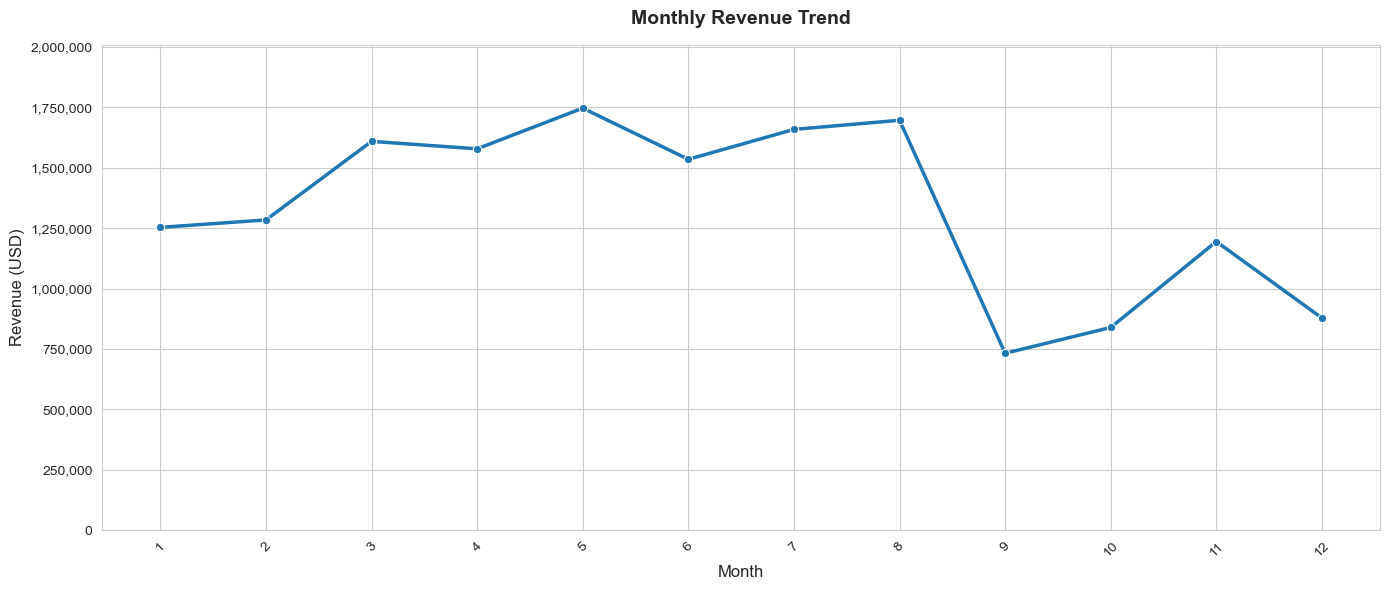

In [79]:
sns.set_style("whitegrid")
plt.figure(figsize=(14, 6))
sns.lineplot(
    data=monthly_revenue,
    x="month",
    y="payment_value",
    marker='o',
    linewidth=2.5,
    color='#1f77b4'
)
plt.ticklabel_format(style='plain', axis='y')
ax = plt.gca()
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: f"{x:,.0f}"))
plt.title("Monthly Revenue Trend", fontsize=14, pad=15, fontweight='bold')
plt.xlabel("Month", fontsize=12)
plt.ylabel("Revenue (USD)", fontsize=12)
plt.xticks(ticks=monthly_revenue["month"], rotation=45)
plt.ylim(0, monthly_revenue['payment_value'].max() * 1.15)
plt.tight_layout()
plt.show()

# Báo cáo Phân tích Xu hướng Doanh thu Hàng tháng (Monthly Revenue Trend)

## 1. Tổng quan về Biểu đồ và Dữ liệu
* **Nguồn dữ liệu tham chiếu:** Bảng số liệu chi tiết sắp xếp theo giá trị từ lớn đến bé  và Biểu đồ đường xu hướng thời gian .
* **Loại biểu đồ:** Biểu đồ đường (Line chart) có các điểm đánh dấu giá trị (markers).
* **Tiêu đề:** Monthly Revenue Trend (Xu hướng doanh thu hàng tháng).
* **Trục tung (Y-axis):** Revenue (USD) - Doanh thu tính theo đơn vị đô la Mỹ (dao động từ mốc 0 đến 2,000,000 USD).
* **Trục hoành (X-axis):** Month - Các tháng trong năm (từ tháng 1 đến tháng 12).

---

## 2. Số liệu Chi tiết từ Dữ liệu (Sắp xếp theo thứ tự thời gian)

Kết hợp từ hai tệp `image_4ce143.png` và `image_4cde81.png`, giá trị doanh thu chính xác của các tháng được ghi nhận như sau:

* **Tháng 1:** 1,253,492.22 USD
* **Tháng 2:** 1,284,371.35 USD
* **Tháng 3:** 1,609,515.72 USD
* **Tháng 4:** 1,578,573.51 USD
* **Tháng 5:** 1,746,900.97 USD *(Đỉnh điểm - Peak)*
* **Tháng 6:** 1,535,156.88 USD
* **Tháng 7:** 1,658,923.67 USD
* **Tháng 8:** 1,696,821.64 USD
* **Tháng 9:** 732,454.23 USD *(Chạm đáy - Trough)*
* **Tháng 10:** 839,358.03 USD
* **Tháng 11:** 1,194,882.80 USD
* **Tháng 12:** 878,421.10 USD

---

## 3. Nhận xét và Đánh giá (Insights)

* **Giai đoạn hiệu suất cao duy trì ổn định (Tháng 3 - Tháng 8):**
  * Doanh thu của doanh nghiệp tăng trưởng mạnh mẽ và giữ vững phong độ ổn định trên mức 1.5 triệu USD/tháng trong suốt 6 tháng liên tiếp (từ tháng 3 đến tháng 8).
  * **Đỉnh điểm doanh thu:** Rơi vào **Tháng 5** với giá trị đạt cao nhất toàn hệ thống là **1,746,900.97 USD**. Tháng 8 theo sát phía sau và là tháng có doanh thu cao thứ hai với **1,696,821.64 USD**.

* **Cú sụt giảm nghiêm trọng vào Tháng 9:**
  * Điểm biến động mạnh nhất của biểu đồ xu hướng là sự suy giảm đột ngột và sâu sắc vào **Tháng 9**, khi doanh thu lao dốc thẳng đứng từ mức gần 1.7 triệu USD (Tháng 8) xuống chỉ còn **732,454.23 USD** (giảm hơn một nửa). Đây cũng là tháng ghi nhận doanh thu thấp nhất trong năm.

* **Sự phục hồi ngắn hạn và kết thúc năm:**
  * Sau khi chạm đáy vào tháng 9, doanh thu có xu hướng hồi phục dần trong tháng 10 và bứt phá trở lại mức trên 1.1 triệu USD vào tháng 11. 
  * Tuy nhiên, đà hồi phục này không giữ được lâu khi tháng 12 tiếp tục chứng kiến một sự sụt giảm nhẹ khác xuống còn **878,421.10 USD**.

In [82]:
monthly_order = (sales_df.groupby('month')['order_id'].nunique().reset_index().sort_values('order_id', ascending= False))
monthly_order

,month,order_id
7,8,10843
4,5,10573
6,7,10318
2,3,9893
5,6,9412
3,4,9343
1,2,8508
0,1,8069
10,11,7544
11,12,5674


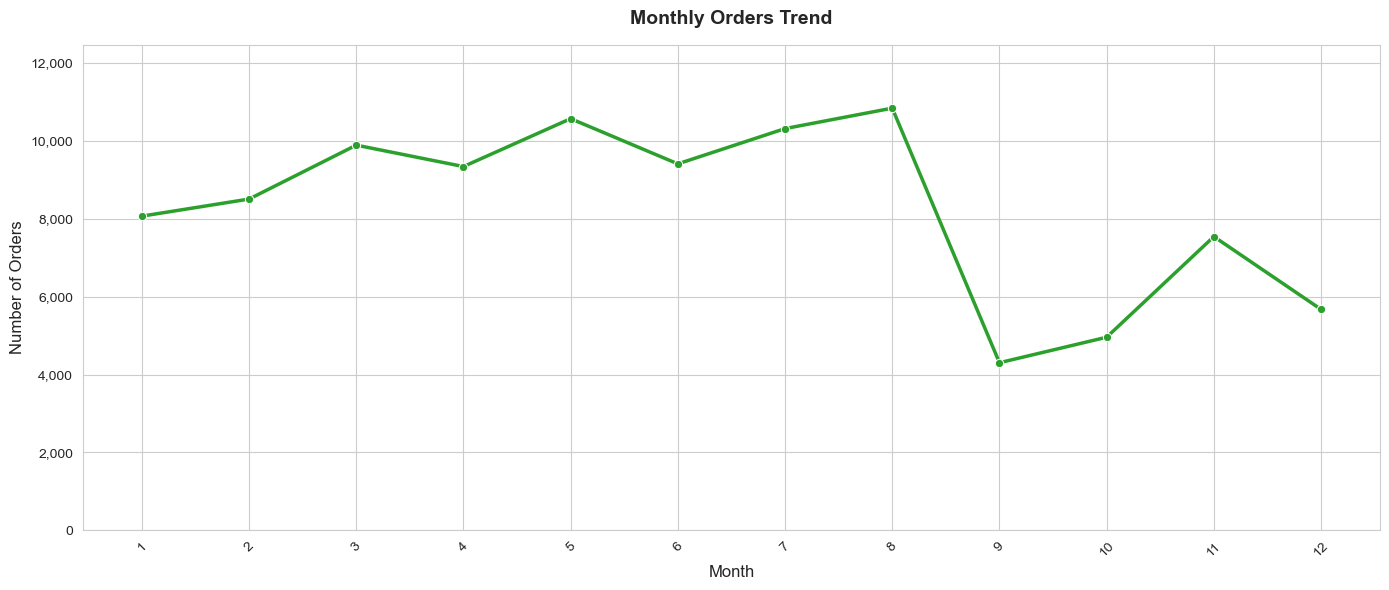

In [87]:
plt.figure(figsize=(14, 6))
ax = sns.lineplot(
    data=monthly_order,
    x="month",
    y="order_id",
    marker='o',
    linewidth=2.5,
    color='#2ca02c' 
)
plt.ticklabel_format(style='plain', axis='y')
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: f"{x:,.0f}"))
plt.xticks(ticks=monthly_order["month"], rotation=45)
plt.title("Monthly Orders Trend", fontsize=14, pad=15, fontweight='bold')
plt.xlabel("Month", fontsize=12)
plt.ylabel("Number of Orders", fontsize=12)
plt.ylim(0, monthly_order['order_id'].max() * 1.15)
plt.tight_layout()
plt.show()

# Báo cáo Phân tích Xu hướng Số lượng Đơn hàng Hàng tháng (Monthly Orders Trend)

## 1. Tổng quan về Biểu đồ và Dữ liệu
* **Nguồn dữ liệu tham chiếu:** Bảng số liệu chi tiết số lượng đơn hàng sắp xếp theo giá trị giảm dần  và Biểu đồ đường xu hướng .
* **Loại biểu đồ:** Biểu đồ đường (Line chart) có các điểm đánh dấu giá trị (markers).
* **Tiêu đề:** Monthly Orders Trend (Xu hướng số lượng đơn hàng hàng tháng).
* **Trục tung (Y-axis):** Number of Orders - Số lượng đơn hàng (dao động từ mốc 0 đến 12,000 đơn).
* **Trục hoành (X-axis):** Month - Các tháng trong năm (từ tháng 1 đến tháng 12).

---

## 2. Số liệu Chi tiết từ Dữ liệu (Sắp xếp theo thứ tự thời gian)

Số lượng đơn hàng chính xác của từng tháng được ghi nhận như sau:

* **Tháng 1:** 8,069 đơn hàng
* **Tháng 2:** 8,508 đơn hàng
* **Tháng 3:** 9,893 đơn hàng
* **Tháng 4:** 9,343 đơn hàng
* **Tháng 5:** 10,573 đơn hàng
* **Tháng 6:** 9,412 đơn hàng
* **Tháng 7:** 10,318 đơn hàng
* **Tháng 8:** 10,843 đơn hàng *(Đỉnh điểm - Peak)*
* **Tháng 9:** 4,304 đơn hàng *(Chạm đáy - Trough)*
* **Tháng 10:** 4,959 đơn hàng
* **Tháng 11:** 7,544 đơn hàng
* **Tháng 12:** 5,674 đơn hàng

---

## 3. Nhận xét và Đánh giá (Insights)

* **Giai đoạn đạt hiệu suất cao và ổn định (Tháng 3 - Tháng 8):**
  * Số lượng đơn hàng duy trì ở mức cao và tương đối ổn định (đều đặn trên 9,000 đơn/tháng) trong suốt giai đoạn từ tháng 3 đến tháng 8.
  * **Đỉnh điểm số lượng đơn hàng:** Xu hướng tăng trưởng đạt mốc cao nhất vào **Tháng 8** với **10,843 đơn hàng**. Tháng 5 bám sát ngay sau với vị trí thứ hai đạt **10,573 đơn hàng**.

* **Cú lao dốc đột ngột vào Tháng 9:**
  * Biến động mạnh nhất trên biểu đồ xảy ra vào **Tháng 9**, khi số lượng đơn hàng sụt giảm nghiêm trọng từ mốc đỉnh hơn 10.8 nghìn đơn xuống chỉ còn **4,304 đơn hàng** (giảm khoảng 60%). Đây cũng là thời điểm lượng đơn hàng chạm mức thấp nhất trong toàn bộ năm.

* **Sự hồi phục cuối năm và biến động Tháng 12:**
  * Sau khi chạm đáy, lượng đơn hàng có tín hiệu phục hồi dần trong tháng 10 và bật tăng mạnh mẽ trở lại vào tháng 11 với **7,544 đơn hàng**.
  * Tuy nhiên, đà phục hồi này bị chững lại khi tháng 12 chứng kiến một đợt sụt giảm khác, đưa số lượng đơn hàng về mức **5,674 đơn**.

# Customer Analysis 

In [90]:
customer_df = pd.read_sql(
    "SELECT * FROM vw_customer_analysis",
    engine
)

In [91]:
customer_df.head()

,customer_unique_id,customer_state,total_orders,total_spending
0,0000366f3b9a7992bf8c76cfdf3221e2,SP,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,SP,1,27.19
2,0000f46a3911fa3c0805444483337064,SC,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,PA,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,SP,1,196.89


In [92]:
customer_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96135 entries, 0 to 96134
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_unique_id  96135 non-null  object 
 1   customer_state      96135 non-null  object 
 2   total_orders        96135 non-null  int64  
 3   total_spending      96135 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 2.9+ MB


In [93]:
customer_df.shape

(96135, 4)

In [94]:
total_customers = customer_df["customer_unique_id"].nunique()
print(f"Total Customers: {total_customers:,}")

Total Customers: 96,095


In [96]:
customer_state_dist = (customer_df
    .groupby("customer_state")
    .size()
    .reset_index(name="customer_count")
    .sort_values("customer_count",ascending=False)
)
customer_state_dist.head()

,customer_state,customer_count
25,SP,40301
18,RJ,12384
10,MG,11259
22,RS,5277
17,PR,4882


C:\Users\Minh Doan\AppData\Local\Temp\ipykernel_15560\952383885.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


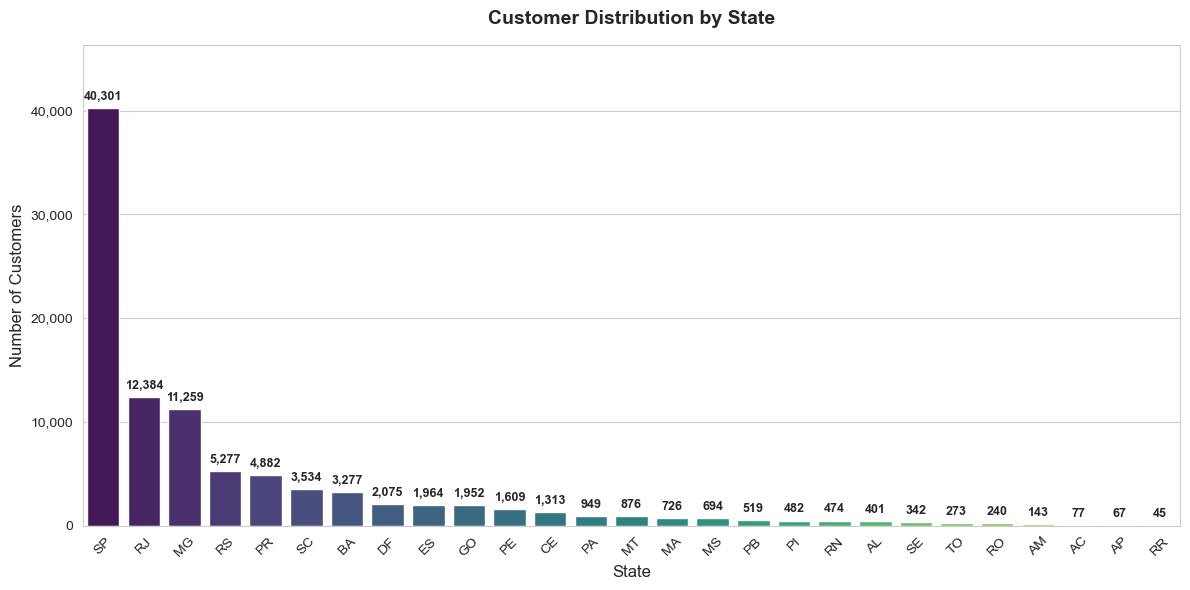

In [97]:
sns.set_style("whitegrid")
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=customer_state_dist,
    x="customer_state",
    y="customer_count",
    palette="viridis"
)
plt.ticklabel_format(style='plain', axis='y')
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: f"{x:,.0f}"))
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f"{height:,.0f}", 
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='center', 
                    xytext=(0, 8), 
                    textcoords='offset points', 
                    fontweight='bold',
                    fontsize=9)
plt.title("Customer Distribution by State", fontsize=14, pad=15, fontweight='bold')
plt.xlabel("State", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)
plt.xticks(rotation=45)
plt.ylim(0, customer_state_dist['customer_count'].max() * 1.15)
plt.tight_layout()
plt.show()

# Báo cáo Phân tích Phân bổ Khách hàng theo Bang (Customer Distribution by State)

## 1. Tổng quan về Biểu đồ và Dữ liệu
* **Nguồn dữ liệu:** Đoạn mã xử lý dữ liệu Pandas sử dụng hàm `.groupby()` kết hợp `.size()` trên biến `customer_df` và biểu đồ cột tần suất tương ứng.
* **Loại biểu đồ:** Biểu đồ cột đứng (Bar chart) hiển thị nhãn giá trị chính xác trên đầu mỗi cột.
* **Tiêu đề:** Customer Distribution by State (Phân bổ khách hàng theo Bang).
* **Trục tung (Y-axis):** Number of Customers - Số lượng khách hàng (dao động từ mốc 0 đến hơn 40,000).
* **Trục hoành (X-axis):** State - Viết tắt tên các bang (ví dụ dựa trên tập dữ liệu này: SP là São Paulo, RJ là Rio de Janeiro, MG là Minas Gerais,... thuộc thị trường Brazil).

---

## 2. Số liệu Chi tiết của Top 5 Bang Dẫn đầu
Dựa trên bảng số liệu từ mã nguồn và biểu đồ, 5 bang có lượng khách hàng lớn nhất được ghi nhận chính xác là:
1. **SP (São Paulo):** 40,301 khách hàng
2. **RJ (Rio de Janeiro):** 12,384 khách hàng
3. **MG (Minas Gerais):** 11,259 khách hàng
4. **RS (Rio Grande do Sul):** 5,277 khách hàng
5. **PR (Paraná):** 4,882 khách hàng

---

## 3. Nhận xét và Đánh giá (Insights)

### Sự tập trung thị trường cực kỳ lớn tại bang SP
* Bang **SP** hiển thị một sự áp đảo hoàn toàn và là thị trường cốt lõi của doanh nghiệp. Với **40,301 khách hàng**, lượng người dùng tại bang này cao gấp gần **3.3 lần** so với bang đứng ở vị trí thứ hai là RJ.
* Riêng lượng khách hàng tại SP lớn hơn tổng lượng khách hàng của nhiều bang khác trên biểu đồ cộng lại, chứng tỏ đây là khu vực mang lại nguồn doanh thu hoặc tệp khách hàng trọng điểm nhất cho hệ thống.

### Nhóm thị trường tiềm năng (RJ và MG)
* Hai bang **RJ** (12,384) và **MG** (11,259) tạo thành nhóm thị trường thứ cấp ổn định. Lượng khách hàng giữa hai bang này có sự chênh lệch rất nhỏ (chỉ khoảng hơn 1,100 khách hàng), giữ khoảng cách an toàn so với nhóm phía sau.

### Hiệu ứng đuôi dài (Long-tail Effect) về phía các bang cuối
* Biểu đồ thể hiện rất rõ quy luật "Đuôi dài" (Long-tail) trong kinh doanh. Càng về phía bên phải trục hoành, lượng khách hàng giảm dần và duy trì ở mức rất thấp đối với một loạt các bang cuối danh sách. 
* Bang **RR** nằm ở vị trí bét bảng với chỉ vỏn vẹn **45 khách hàng**, cho thấy sự hiện diện thương mại của doanh nghiệp tại khu vực này gần như chưa đáng kể.

---



In [101]:
top_customers = (customer_df.sort_values("total_spending",ascending=False).head(20))
top_customers.head()

,customer_unique_id,customer_state,total_orders,total_spending
3826,0a0a92112bd4c708ca5fde585afaa872,RJ,1,13664.08
26461,46450c74a0d8c5ca9395da1daac6c120,SC,3,9553.02
81994,da122df9eeddfedc1dc1f5349a1a690c,RJ,2,7571.63
44462,763c8b1c9c68a0229c42c9fc6f662b93,ES,1,7274.88
82840,dc4802a71eae9be1dd28f5d788ceb526,MS,1,6929.31


C:\Users\Minh Doan\AppData\Local\Temp\ipykernel_15560\4074237396.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


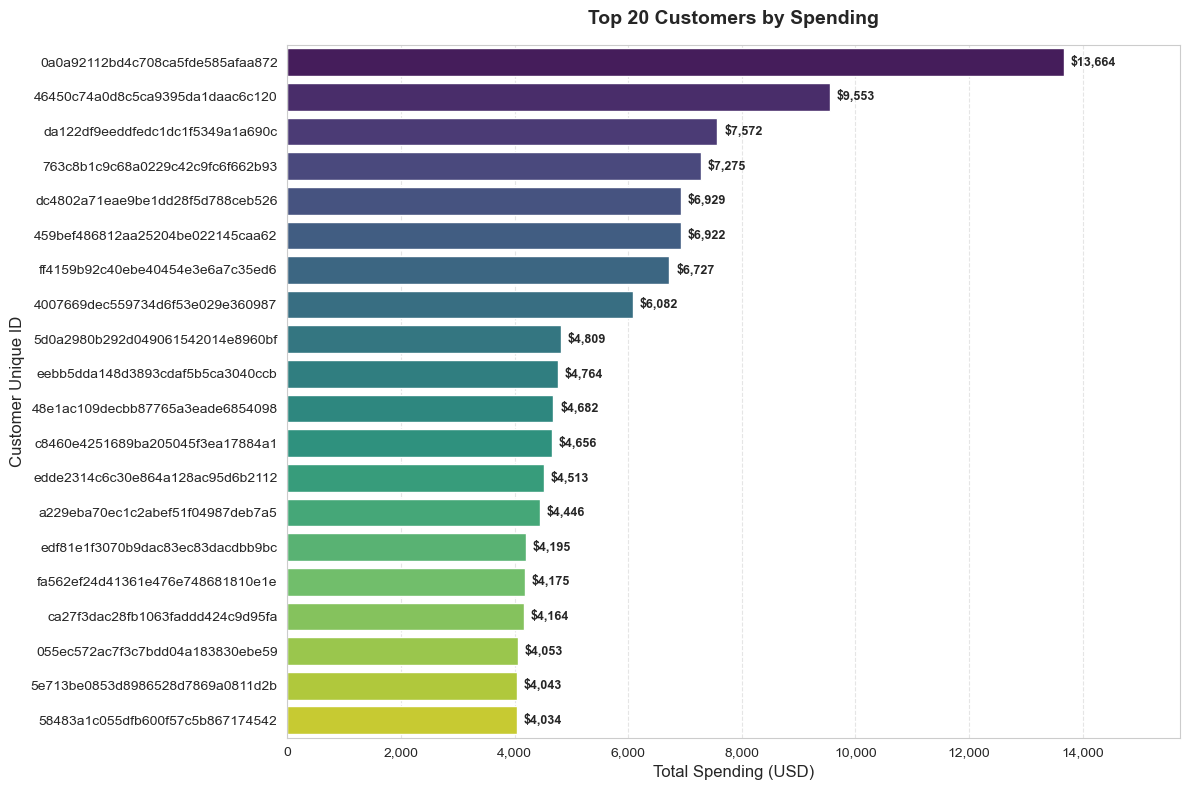

In [102]:
sns.set_style("whitegrid")
plt.figure(figsize=(12, 8))
ax = sns.barplot(
    data=top_customers,
    x="total_spending",
    y="customer_unique_id",
    palette="viridis"
)
plt.ticklabel_format(style='plain', axis='x')
ax.get_xaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: f"{x:,.0f}"))
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.annotate(f"${width:,.0f}", 
                    (width, p.get_y() + p.get_height() / 2.),
                    ha='left', va='center', 
                    xytext=(5, 0), 
                    textcoords='offset points', 
                    fontweight='bold',
                    fontsize=9)
plt.title("Top 20 Customers by Spending", fontsize=14, pad=15, fontweight='bold')
plt.xlabel("Total Spending (USD)", fontsize=12)
plt.ylabel("Customer Unique ID", fontsize=12)
plt.xlim(0, top_customers['total_spending'].max() * 1.15)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [105]:
top_order_customers = (customer_df.sort_values("total_orders", ascending=False).head(20))
top_order_customers

,customer_unique_id,customer_state,total_orders,total_spending
52991,8d50f5eadf50201ccdcedfb9e2ac8455,SP,17,927.63
23476,3e43e6105506432c953e165fb2acf44c,SP,9,1172.66
76109,ca77025e7201e3b30c44b472ff346268,PE,7,1122.72
37807,6469f99c1f9dfae7733b25662e7f1782,SP,7,758.83
10354,1b6c7548a2a1f9037c1fd3ddfed95f33,MG,7,959.01
7175,12f5d6e1cbf93dafd9dcc19095df0b3d,PR,6,110.72
27048,47c1a3033b8b77b3ab6e109eb4d5fdf3,SP,6,944.21
90487,f0e310a6839dce9de1638e0fe5ab282a,ES,6,540.69
83573,de34b16117594161a6a89c50b289d35a,SP,6,660.94
37595,63cfc61cee11cbe306bff5857d00bfe4,RJ,6,826.32


C:\Users\Minh Doan\AppData\Local\Temp\ipykernel_15560\2977397462.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


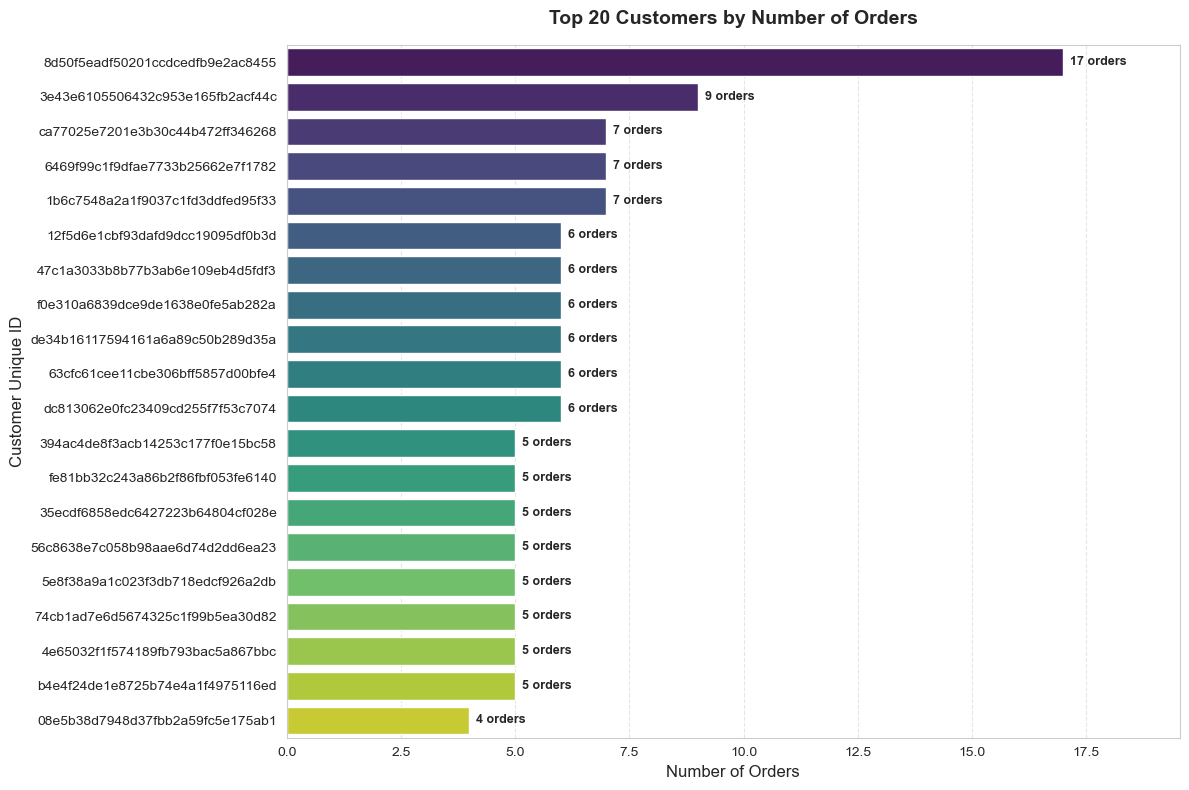

In [106]:
sns.set_style("whitegrid")
plt.figure(figsize=(12, 8))
ax = sns.barplot(
    data=top_order_customers,
    x="total_orders",
    y="customer_unique_id",
    palette="viridis"
)
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.annotate(f"{width:,.0f} orders", 
                    (width, p.get_y() + p.get_height() / 2.),
                    ha='left', va='center', 
                    xytext=(5, 0), 
                    textcoords='offset points', 
                    fontweight='bold',
                    fontsize=9)
plt.title("Top 20 Customers by Number of Orders", fontsize=14, pad=15, fontweight='bold')
plt.xlabel("Number of Orders", fontsize=12)
plt.ylabel("Customer Unique ID", fontsize=12)
plt.xlim(0, top_order_customers['total_orders'].max() * 1.15)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Product Analysis 